In [1]:
%matplotlib inline

In [2]:
from collections import defaultdict
from __future__ import annotations
# In standard Python, dictionaries are incredibly strict. If you ask a standard dictionary for a key it has never seen before,
#  it instantly halts your program and throws a KeyError. A defaultdict fixes this by automatically creating that missing key on the fly
#  and assigning it a default starting value of your choice.
import matplotlib.pyplot as plt# Drawing Plots
from matplotlib.patches import Patch # Drawing shapes
import numpy as np # Data and array manipulation
import seaborn as sns # Data Visualization
from tqdm import tqdm # Shows the loader Bar, Progress
import gymnasium as gym
from IPython.display import clear_output
import time

In [3]:
for i , _ in enumerate(gym.envs.registry): # Available Environments
    print(f"Env {i+1} - {_}")

Env 1 - CartPole-v0
Env 2 - CartPole-v1
Env 3 - MountainCar-v0
Env 4 - MountainCarContinuous-v0
Env 5 - Pendulum-v1
Env 6 - Acrobot-v1
Env 7 - phys2d/CartPole-v0
Env 8 - phys2d/CartPole-v1
Env 9 - phys2d/Pendulum-v0
Env 10 - LunarLander-v3
Env 11 - LunarLanderContinuous-v3
Env 12 - BipedalWalker-v3
Env 13 - BipedalWalkerHardcore-v3
Env 14 - CarRacing-v3
Env 15 - Blackjack-v1
Env 16 - FrozenLake-v1
Env 17 - FrozenLake8x8-v1
Env 18 - CliffWalking-v1
Env 19 - CliffWalkingSlippery-v1
Env 20 - Taxi-v4
Env 21 - tabular/Blackjack-v0
Env 22 - tabular/CliffWalking-v0
Env 23 - Reacher-v2
Env 24 - Reacher-v4
Env 25 - Reacher-v5
Env 26 - Pusher-v2
Env 27 - Pusher-v4
Env 28 - Pusher-v5
Env 29 - InvertedPendulum-v2
Env 30 - InvertedPendulum-v4
Env 31 - InvertedPendulum-v5
Env 32 - InvertedDoublePendulum-v2
Env 33 - InvertedDoublePendulum-v4
Env 34 - InvertedDoublePendulum-v5
Env 35 - HalfCheetah-v2
Env 36 - HalfCheetah-v3
Env 37 - HalfCheetah-v4
Env 38 - HalfCheetah-v5
Env 39 - Hopper-v2
Env 40 - Ho

In [4]:
env = gym.make('Blackjack-v1', sab = True, render_mode = 'rgb_array') # 'rgb_array' -> only gives array values
print(env.action_space)

Discrete(2)


# Observing the Environment

In [5]:
# reset the environment to get the first observation
done = False
observation, info = env.reset()
# Observation structure: (16,9,False) -> (Player's Sum, Value of Dealer's Face Up Card, Usuable Ace)
print(info)

{}


In [6]:
action = env.action_space.sample() # Sampling a random action from all valid action
observation, reward, terminated, truncated, info = env.step(action) # Executing the action in the environment and receieve info after taking the step

# observation = (24,10,False)
# reward = -1.0
# terminated = True
# truncated  = False
# info = {}
print(action) # Prints 0 or 1

1


Once ``terminated = True`` or ``truncated=True``, we should stop the current episode and begin a new one with ``env.reset()``. If you continue executing actions without resetting the environment, it still responds but the output won’t be useful for training (it might even be harmful if the agent learns on invalid data).

# Epsilon - Greedy Strategy Approach

In [7]:
class BlackJackAgent:
    def __init__(self, learning_rate : float, initial_epsilon : float, epsilon_decay : float, final_epsilon : float, discount_factor : float = 0.95):
        self.q_values = defaultdict(lambda:np.zeros(env.action_space.n)) # initialize an empty dictionary of state-action values if not seen before, 'env.action_space.n' is the number of elements in the action space
        # 'env.action_space.n' -> returns 2. So [0,0] if state action pair is not in the Q-table
        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []

    def get_action(self, obs:tuple[int,int,bool]): # Selects the random action with 'epsilon' probability and the greedy action with '1-epsilon' probability. 
        if np.random.random() < self.epsilon: # Random Action
            return env.action_space.sample()
        else:
            return int(np.argmax(self.q_values[obs])) # 'self.q_values[obs]' gives the 'value' in the key-value pair and 'np.argmax' gives the index of the action with the better estimate
    
    def update(self, obs:tuple[int,int,bool], action:int, reward:float, terminated:bool, next_obs:tuple[int,int,bool]): # This function is used to update the Q-value of the action
        if terminated == False:
            temporal_difference =  ((reward + self.discount_factor * np.max(self.q_values[next_obs])) - self.q_values[obs][action])
        else:
            temporal_difference =  ((reward + self.discount_factor * 0) - self.q_values[obs][action])

        self.q_values[obs][action] += self.lr * temporal_difference
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

The ``Q-value function`` is used to calculate the optimal action in each state.

# Training Loop

In [ ]:
# RUN THIS CELL ONLY ONCE in a Kernel instance
# Hyperparameters
learning_rate = 0.01
n_episodes = 10
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2) # reduce the exploration over time
final_epsilon = 0.1

agent = BlackJackAgent(learning_rate = learning_rate, initial_epsilon = start_epsilon, epsilon_decay = epsilon_decay, final_epsilon = final_epsilon) # Agent is initialized
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)


  0%|          | 0/10 [00:00<?, ?it/s]

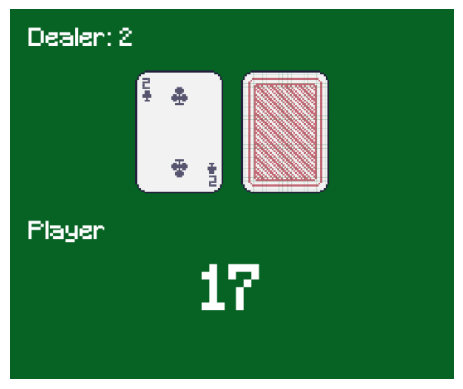

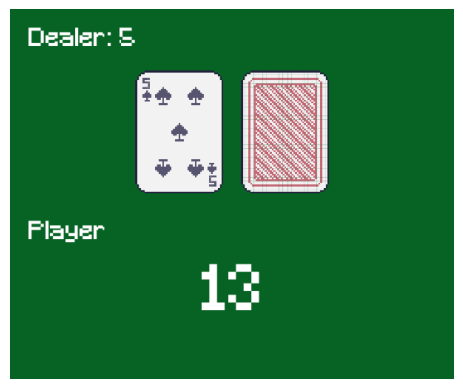

 20%|██        | 2/10 [00:00<00:00, 16.26it/s]

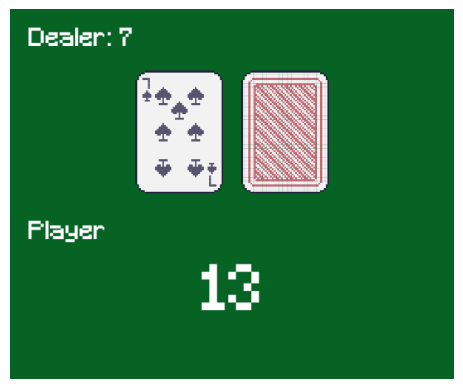

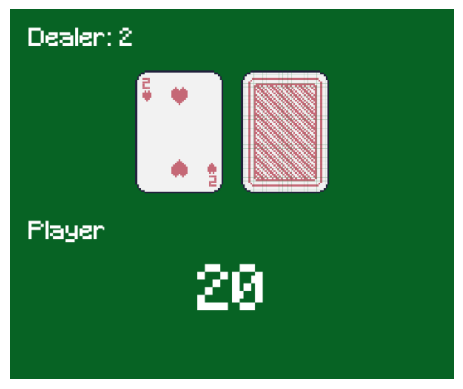

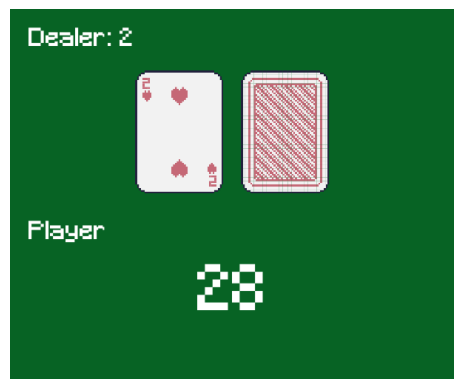

 40%|████      | 4/10 [00:00<00:00, 12.07it/s]

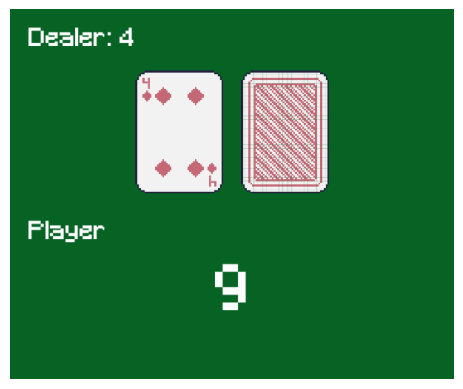

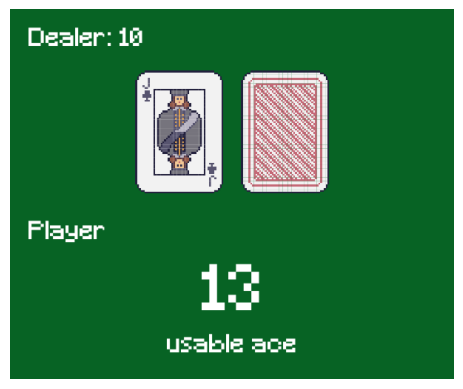

 60%|██████    | 6/10 [00:00<00:00, 13.38it/s]

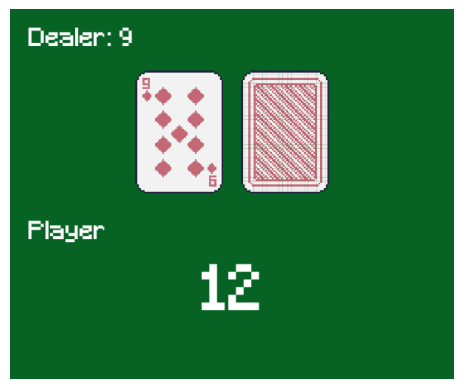

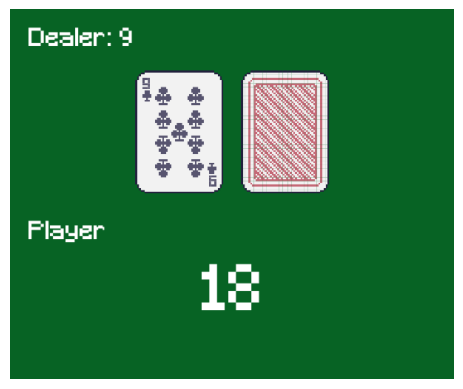

 80%|████████  | 8/10 [00:00<00:00, 13.77it/s]

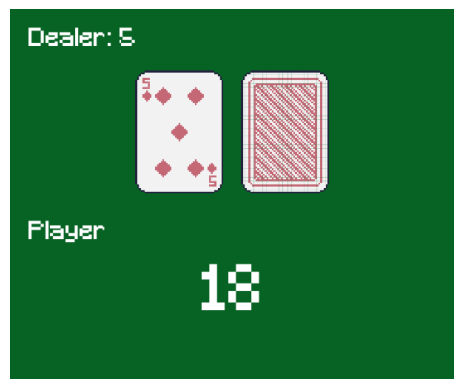

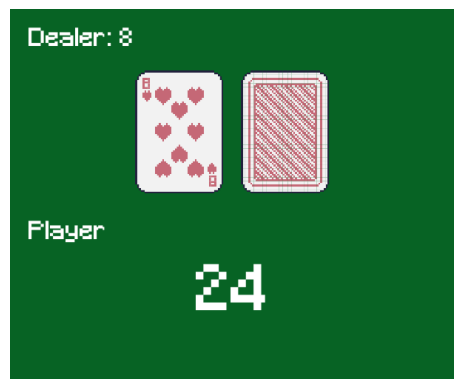

100%|██████████| 10/10 [00:00<00:00, 14.12it/s]


In [14]:
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent.update(obs, action, reward, terminated, next_obs)

        frame = env.render()
        plt.imshow(frame)
        plt.axis('off')
        plt.show()
        
        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()